In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

<br><br>

## 1. Load data

In [101]:
df = pd.read_csv("env_clean.csv")
df.head()

,census_tract,county,location,population,PollutionScore,pm25,diesel_pm,traffic_density,ozone,asthma,cardiovascular_disease,diabetes,low_birth_weight
0,6001400100,Alameda,Berkeley,3094,4.369906,7.135387,0.095739,934.715,0.029251,17.36,7.29,9.1,7.03
1,6001400200,Alameda,Oakland,2093,5.046525,7.348713,0.171673,1753.647,0.028516,20.69,7.04,7.0,4.13
2,6001400300,Alameda,Oakland,5727,4.971513,7.446539,0.155387,1617.707,0.028516,26.72,7.51,7.4,4.51
3,6001400400,Alameda,Oakland,4395,4.986183,7.451338,0.160767,1253.706,0.028516,37.93,8.89,6.5,3.06
4,6001400500,Alameda,Oakland,3822,4.496636,7.451338,0.133439,484.944,0.028516,49.55,9.87,7.2,5.50


<br><br>
<br><br>

## 2. Access all variables and their data types

In [102]:
df["county"] = df["county"].astype("category")
df["location"] = df["location"].astype("category")
df.dtypes

census_tract                 int64
county                    category
location                  category
population                   int64
PollutionScore             float64
pm25                       float64
diesel_pm                  float64
traffic_density            float64
ozone                      float64
asthma                     float64
cardiovascular_disease     float64
diabetes                   float64
low_birth_weight           float64
dtype: object

<br><br>
<br><br>

## 3. Analysis of diseases

<br>

##### **Statistics for disease variables**

In [103]:
disease = ["asthma", "cardiovascular_disease", "diabetes", "low_birth_weight"]
df[disease].describe()

,asthma,cardiovascular_disease,diabetes,low_birth_weight
count,8859.000000,8859.000000,8859.000000,8859.000000
mean,38.360300,14.504499,11.662580,5.552789
std,18.530283,5.113487,2.801279,1.774564
min,0.660000,0.560000,1.900000,0.000000
25%,25.250000,10.460000,9.800000,4.380000
50%,35.540000,13.910000,11.500000,5.460000
75%,47.080000,17.980000,13.500000,6.650000
max,246.070000,37.210000,30.900000,17.390000


<br><br>

##### **Visualizing statistics for disease variables with Histograms**

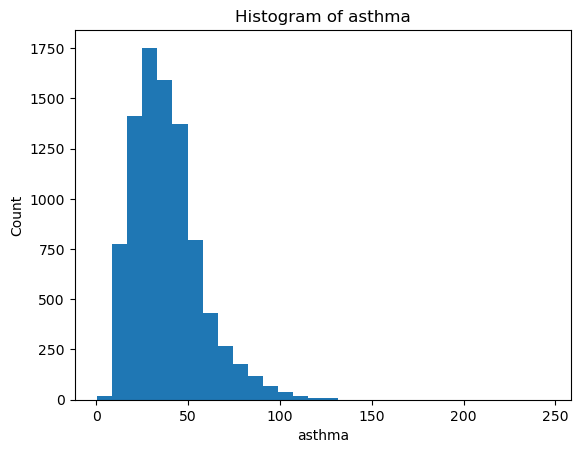

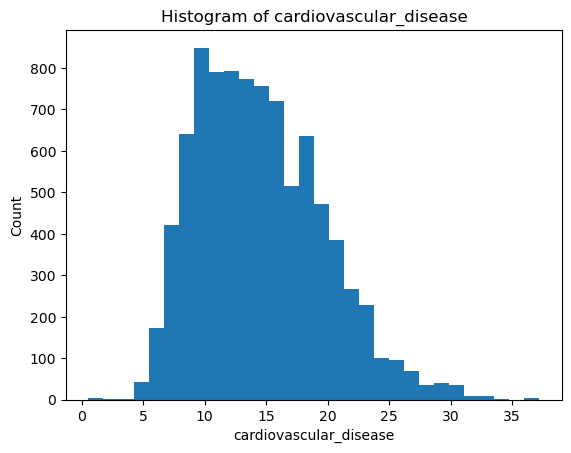

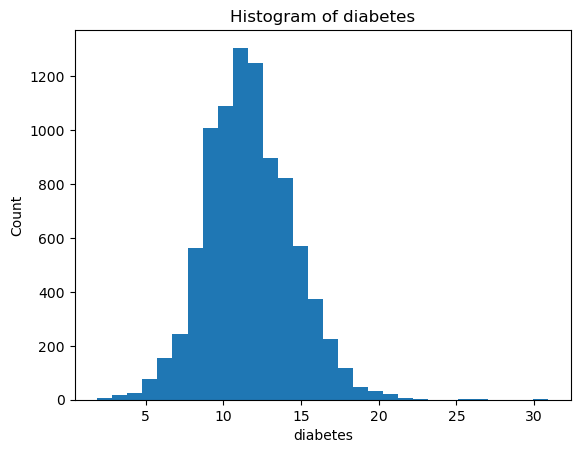

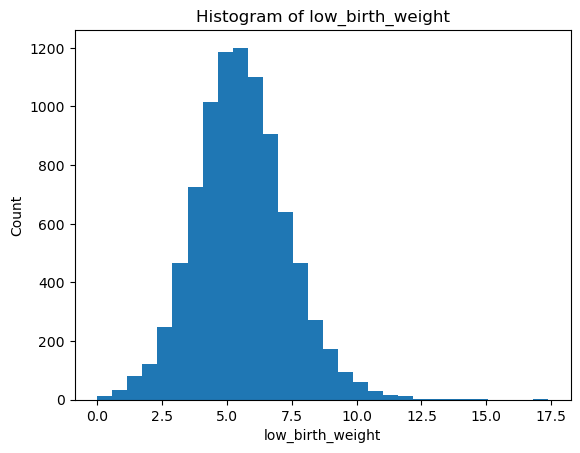

In [104]:
for item in disease:
    plt.hist(df[item], bins=30)
    plt.xlabel(item)
    plt.ylabel("Count")
    plt.title("Histogram of " + item)
    plt.show()

<br><br>

##### **Visualizing statistics for disease variables with Boxplots**

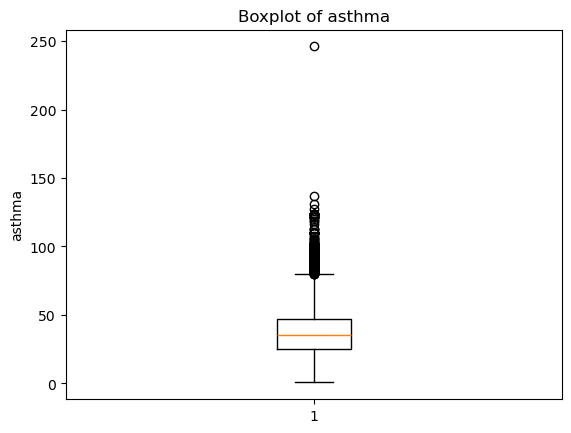

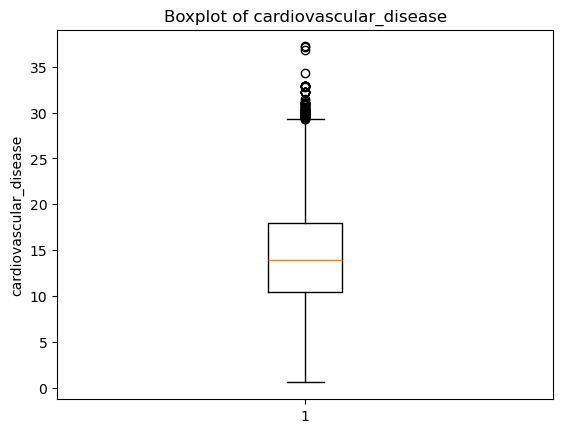

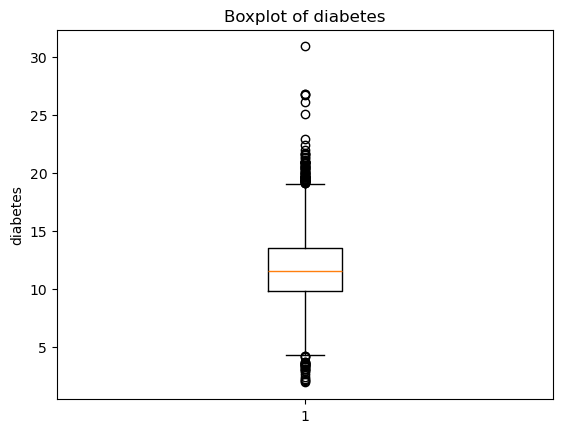

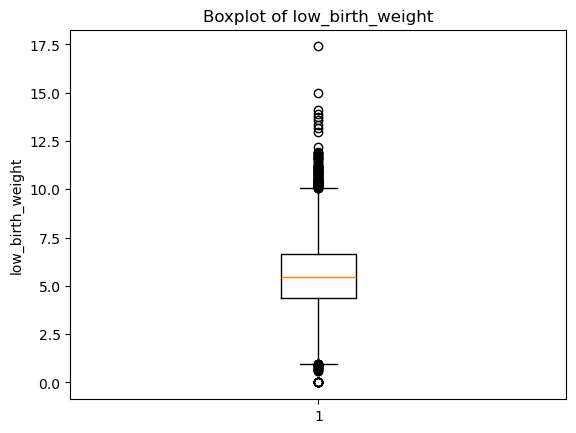

In [105]:
for item in disease:
    plt.boxplot(df[item])
    plt.ylabel(item)
    plt.title("Boxplot of " + item)
    plt.show()

<br>

**Observations**

The histograms showed the distribution of asthma, cardiovascular disease, diabetes, and low birth weight in different communities. The boxplots identified the outliers and extreme statistics of each disease in different communities. The graphs do show a number of outliers with higher statistics of the diseases. 

<br><br>
<br><br>

## 4. Correlation Table and Heatmaps

<br>

##### **Creating correlation table in between each health outcome**

In [106]:
disease_corr = df[disease].corr()
disease_corr

,asthma,cardiovascular_disease,diabetes,low_birth_weight
asthma,1.000000,0.634957,0.497366,0.358404
cardiovascular_disease,0.634957,1.000000,0.531358,0.271183
diabetes,0.497366,0.531358,1.000000,0.281638
low_birth_weight,0.358404,0.271183,0.281638,1.000000


<br><br>

##### **Creating the heatmap from the corrlatoin in between each health outcome**

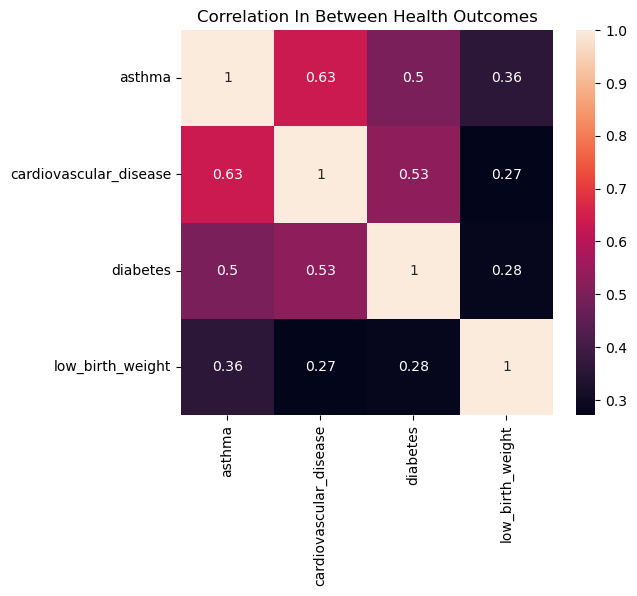

In [107]:
plt.figure(figsize=(6, 5))
sns.heatmap(disease_corr, annot=True)
plt.title("Correlation In Between Health Outcomes")
plt.show()

<br>

**Observations**: 

According to the interior correlation table and heatmap between the health outcomes, we notice some strong correlationships in between the disease variables. For example, the correlationship between cardiovascular disease and asthma, the correlationship between cardiovascular disease and diabetes, and the correlationship between diabetes and asthma, all reach a value over or equal to 0.5, indicating that a number of communities are experiencing multiple health issues at the same time. Whenever one health problem exists in the community, it is likely that other health problems listed above also exist along with the other. In the scatterplot section, we will emphasize on these strongly correlated variables. 

<br><br>

##### **Creating the correlation table between the health outcomes and the pollution variables**

In [108]:
env = ["PollutionScore", "pm25", "diesel_pm", "traffic_density", "ozone"]
all_vars = env + disease
env_disease_corr = df[all_vars].corr()
env_disease_corr.loc[env, disease]

,asthma,cardiovascular_disease,diabetes,low_birth_weight
PollutionScore,0.204982,0.170917,0.281342,0.160486
pm25,0.067397,0.159238,0.258660,0.126660
diesel_pm,0.071558,0.039384,0.058998,0.055404
traffic_density,-0.025345,-0.058983,-0.040471,0.050377
ozone,0.132784,0.477837,0.289704,0.091173


<br><br>

##### **Creating the heatmap from the correlation table between the health outcomes and pollution variables**

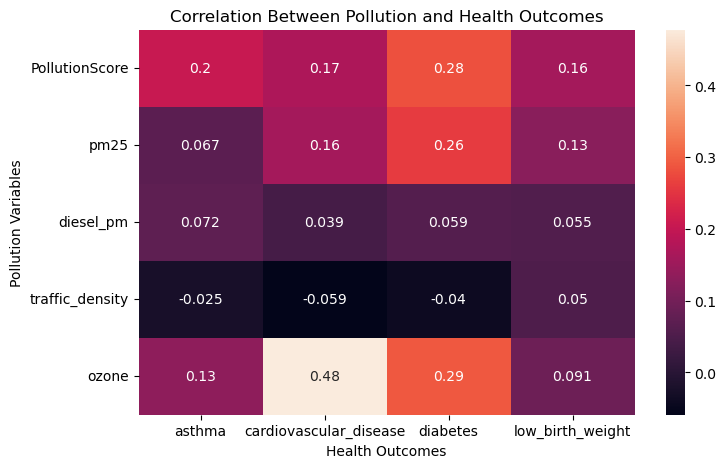

In [109]:
plt.figure(figsize=(8, 5))
sns.heatmap(env_disease_corr.loc[env, disease], annot=True)
plt.title("Correlation Between Pollution and Health Outcomes")
plt.xlabel("Health Outcomes")
plt.ylabel("Pollution Variables")
plt.show()

<br>

**Observations**:

The correlaiton table and healmap between pollution variables and health outcomes showed that there is a relatively strong correlationship between ozone and cardiovascular disease. The other correlationships between pollution variables and health outcomes are not strong, or even have little relationships, which means that the pollution variables we focused on may not be the main factors causing the health problems. However, it is still not certain if the variables are completely independent or if there are outliers in the data that affect the values produced. In the scatterplot section, we will graph both the strong correlation and the weak corerlation to visualize the data better. 

<br><br>
<br><br>

## 5. Scatterplots

<br>

##### **Asthma VS. Cardiovascular Disease**

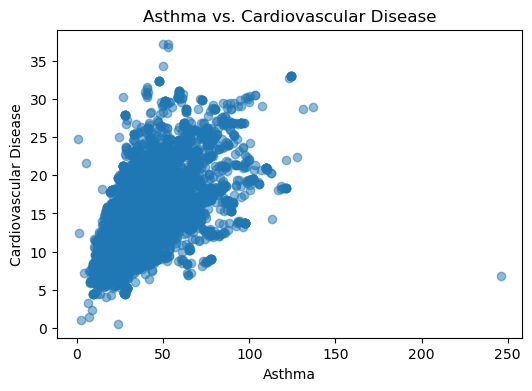

In [110]:
plt.figure(figsize=(6, 4))
plt.scatter(df["asthma"], df["cardiovascular_disease"], alpha=0.5)
plt.xlabel("Asthma")
plt.ylabel("Cardiovascular Disease")
plt.title("Asthma vs. Cardiovascular Disease")
plt.show()

**Observation**: 

The scatterplot between cardiovascular disease and asthma follows an obvious pattern that the two health outcomes are correlated. The two health outcome variables have a positive relationship. 

<br><br>

##### **Ozone VS. Cardiovascular Disease**


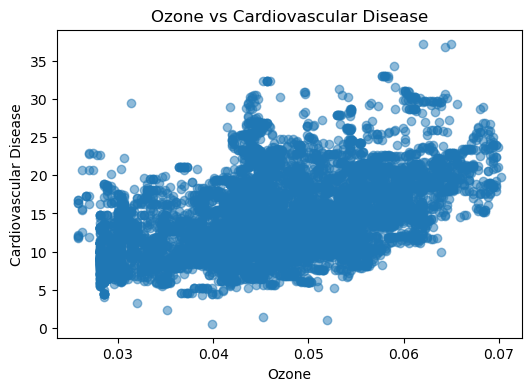

In [111]:
plt.figure(figsize=(6, 4))
plt.scatter(df["ozone"], df["cardiovascular_disease"], alpha=0.5)
plt.xlabel("Ozone")
plt.ylabel("Cardiovascular Disease")
plt.title("Ozone vs Cardiovascular Disease")
plt.show()

**Observations**:

The scatterplot between ozone and cardiovascular disease shows a slight postive relationship pattern. It means that the existence of ozone in the atmosphere is possible to cause the risk of having cardiovascular disease in the community. 

<br><br>

##### **Ozone VS. Diabetes**

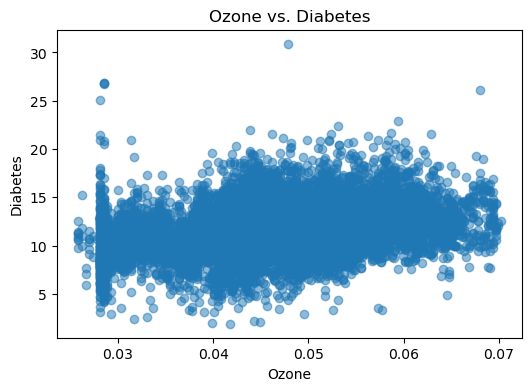

In [112]:
plt.figure(figsize=(6, 4))
plt.scatter(df["ozone"], df["diabetes"], alpha=0.5)
plt.xlabel("Ozone")
plt.ylabel("Diabetes")
plt.title("Ozone vs. Diabetes")
plt.show()

**Observations**:

Looking at the graph, there are quite a few outliers when ozone level stays low that may pull the value of relation between ozone and diabetes lower than it should be if we ignore the outliers. In general, ozone and diabetes have a positive relationship, even though it is not a strong one. 

<br><br>

##### **Pollution Score VS. Diabetes**

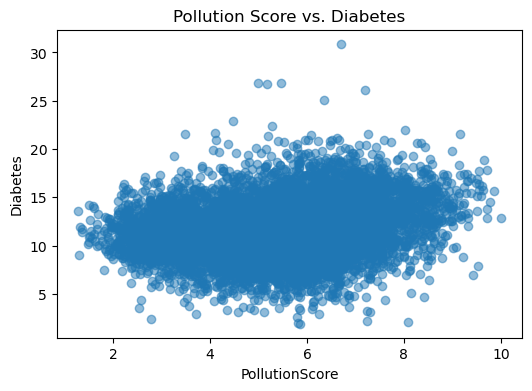

In [113]:
plt.figure(figsize=(6, 4))
plt.scatter(df["PollutionScore"], df["diabetes"], alpha=0.5)
plt.xlabel("PollutionScore")
plt.ylabel("Diabetes")
plt.title("Pollution Score vs. Diabetes")
plt.show()

**Observations**:

The scatterplot between pollution score and diabetes are relatively cleaner than the other relationships. There is few outliers and the data points are arranged in a visually obvious slightly increasing pattern, showing a positive relationship between the two variables. 

<br><br>
<br><br>

## 6. Normalization and VIF

<br>

In [114]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[env] = scaler.fit_transform(df[env])

X = df[env].dropna()
vif_table = pd.DataFrame()
vif_table["Variable"] = X.columns
vif_table["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_table

,Variable,VIF
0,PollutionScore,27.476394
1,pm25,48.328751
2,diesel_pm,1.264880
3,traffic_density,2.629761
4,ozone,20.967433


<br><br>
<br><br>

## 7. Regression

<br>

##### **Regression on Asthma**

In [115]:
target_outcome = "asthma"
formula = target_outcome + " ~ " + " + ".join(env)
model = smf.ols(formula=formula, data=df_scaled).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 asthma   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     159.6
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          7.21e-163
Time:                        11:39:42   Log-Likelihood:                -38051.
No. Observations:                8859   AIC:                         7.611e+04
Df Residuals:                    8853   BIC:                         7.616e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          38.3603      0.189    203.379      0.000      37.991      38.730
PollutionScore      6.4598      0.273     23.645      0.000       5.924       6.995
pm25               -3.4327      0.267    -12.863      0.000      -3.956      -2.910
diesel_pm           0.5874      0.196      3.002      0.003       0.204       0.971
traffic_density    -2.2917      0.208    -11.041      0.000      -2.699      -1.885
ozone               2.5513      0.202     12.633      0.000       2.155       2.947
==============================================================================
Omnibus:                     2364.977   Durbin-Watson:                   0.295
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8115.100
Skew:                           1.328   Prob(JB):                         0.00
Kurtosis:                       6.865   Cond. No.                         2.69
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations**:

The R-squared of regression on asthma is 0.083, so the data of pollution variables only explains 8.3% of the results of asthma. Given that the p values for the 5 pollution variables are all smaller than 0.05, all the variables are significant in the regression. The coefficients of the pollution variables indicate that holding other variable values constant, pollution score, diesel pm, and ozone are positively associated with asthma, while PM2.5 and traffic density are negatively associated with asthma.

<br><br>

##### **Regression on Cardiovascular Disease**

In [116]:
target_outcome = "cardiovascular_disease"
formula = target_outcome + " ~ " + " + ".join(env)
model = smf.ols(formula=formula, data=df_scaled).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     cardiovascular_disease   R-squared:                       0.256
Model:                                OLS   Adj. R-squared:                  0.255
Method:                     Least Squares   F-statistic:                     608.4
Date:                    Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                            11:39:42   Log-Likelihood:                -25718.
No. Observations:                    8859   AIC:                         5.145e+04
Df Residuals:                        8853   BIC:                         5.149e+04
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          14.5045      0.047    309.379      0.000      14.413      14.596
PollutionScore      1.0917      0.068     16.077      0.000       0.959       1.225
pm25               -0.6195      0.066     -9.340      0.000      -0.750      -0.489
diesel_pm           0.1282      0.049      2.636      0.008       0.033       0.224
traffic_density    -0.5823      0.052    -11.285      0.000      -0.683      -0.481
ozone               2.4700      0.050     49.202      0.000       2.372       2.568
==============================================================================
Omnibus:                      672.480   Durbin-Watson:                   0.257
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              857.714
Skew:                           0.690   Prob(JB):                    5.62e-187
Kurtosis:                       3.646   Cond. No.                         2.69
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations**:

The data of pollution variables explains 25.6% of the results of cardiovascular disease. The variables are all statistically significant. Keeping other variables constant, increase in pollution score, diesel pm, and ozone will increase the existence of cardiovascular disease, while increase in PM2.5 and traffic density will decrease the existence of cardiovascular disease instead. 

<br><br>

##### **Regression on Diabetes**

In [117]:
target_outcome = "diabetes"
formula = target_outcome + " ~ " + " + ".join(env)
model = smf.ols(formula=formula, data=df_scaled).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               diabetes   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     344.6
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        11:39:42   Log-Likelihood:                -20908.
No. Observations:                8859   AIC:                         4.183e+04
Df Residuals:                    8853   BIC:                         4.187e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          11.6626      0.027    428.180      0.000      11.609      11.716
PollutionScore      0.8115      0.039     20.569      0.000       0.734       0.889
pm25                0.0749      0.039      1.943      0.052      -0.001       0.150
diesel_pm           0.0303      0.028      1.073      0.284      -0.025       0.086
traffic_density    -0.4594      0.030    -15.326      0.000      -0.518      -0.401
ozone               0.6501      0.029     22.289      0.000       0.593       0.707
==============================================================================
Omnibus:                      313.624   Durbin-Watson:                   0.821
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              676.304
Skew:                           0.227   Prob(JB):                    1.39e-147
Kurtosis:                       4.276   Cond. No.                         2.69
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations**: 

The data of pollution variables explains 16.3% of the results of cardiovascular disease. The p value for PM2.5 is 0.052 > 0.05, and the p value for diesel pm is 0.284 > 0.05, so except PM2.5 and diesel pm, the other variables are significant. Keeping other variables constant, increase in pollution score, PM2.5, diesel pm, and ozone will increase the existence of cardiovascular disease, while increase in traffic density will decrease the existence of cardiovascular disease instead. 

<br><br>

##### **Regression on Low Birth Weight**

In [118]:
target_outcome = "low_birth_weight"
formula = target_outcome + " ~ " + " + ".join(env)
model = smf.ols(formula=formula, data=df_scaled).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       low_birth_weight   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     55.98
Date:                Wed, 03 Jun 2026   Prob (F-statistic):           1.72e-57
Time:                        11:39:42   Log-Likelihood:                -17513.
No. Observations:                8859   AIC:                         3.504e+04
Df Residuals:                    8853   BIC:                         3.508e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           5.5528      0.019    299.054      0.000       5.516       5.589
PollutionScore      0.2560      0.027      9.520      0.000       0.203       0.309
pm25                0.0155      0.026      0.591      0.554      -0.036       0.067
diesel_pm           0.0361      0.019      1.877      0.061      -0.002       0.074
traffic_density    -0.0231      0.020     -1.131      0.258      -0.063       0.017
ozone               0.1151      0.020      5.788      0.000       0.076       0.154
==============================================================================
Omnibus:                      336.335   Durbin-Watson:                   1.560
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              470.866
Skew:                           0.385   Prob(JB):                    5.66e-103
Kurtosis:                       3.826   Cond. No.                         2.69
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Observations**:

The data of pollution variables explains only 3.1% of the results of cardiovascular disease. he p value for PM2.5 is 0.554 > 0.05, the p value for diesel pm is 0.061 > 0.05, and the p value for traffic density is 0.258 > 0.05, so only pollution score and ozone are significant. Keeping other variables constant, increase in pollution score, PM2.5, diesel pm, and ozone will increase the existence of cardiovascular disease, while increase in traffic density will decrease the existence of cardiovascular disease instead. 

<br><br>
<br><br>

## 8. Community EDA

<br>

##### **Top 10 counties with highest pollution burden**

In [119]:
df_scaled["pollution_mean"] = df_scaled[env].mean(axis=1)
df_sorted = df_scaled.sort_values("pollution_mean", ascending=False)
df_sorted.head(10)

,census_tract,county,location,population,PollutionScore,pm25,diesel_pm,traffic_density,ozone,asthma,cardiovascular_disease,diabetes,low_birth_weight,pollution_mean
1582,6037127520,Los Angeles,Van Nuys,4868,0.881816,0.965598,45.328522,2.565177,1.076910,40.94,19.58,15.8,6.57,10.163605
1479,6037117408,Los Angeles,North Hills,2505,0.675811,0.826384,28.124088,2.732683,1.104536,44.31,17.41,15.2,7.45,6.692700
6405,6073010402,San Diego,Imperial Beach,5442,0.367302,0.598354,26.019389,-0.936120,-0.607169,38.76,15.25,11.2,2.52,5.088351
4263,6059042108,Orange,San Clemente,5784,0.016896,0.196254,24.595721,0.295647,-0.049859,13.69,11.07,8.3,4.20,5.010932
5686,6071000307,San Bernardino,Montclair,2786,1.265589,0.726472,18.725137,-0.725568,1.505847,46.20,20.53,16.7,7.91,4.299495
1043,6025012201,Imperial,Calexico,4299,1.442756,0.101618,17.280995,-0.111507,0.706841,27.78,27.94,19.4,2.77,3.884141
1041,6025012101,Imperial,Calexico,3146,1.168367,0.123671,17.053941,-0.155712,0.696495,27.78,27.94,20.4,3.67,3.777352
2842,6037480702,Los Angeles,South Pasadena,4501,0.471213,1.123757,13.246270,-0.440676,0.609531,22.50,9.59,10.9,2.71,3.002019
4522,6059086406,Orange,Anaheim,4000,1.904578,1.434945,6.567386,4.822201,0.075094,39.22,13.13,10.3,6.19,2.960841
6223,6073005102,San Diego,San Diego,4673,0.713435,0.597526,13.851941,-0.469004,-0.656943,40.34,9.66,6.9,4.57,2.807391


<br><br>

##### **Top 10 counties with highest health burden**

In [120]:
df_scaled["health_mean"] = df_scaled[disease].mean(axis=1)
df_sorted = df_scaled.sort_values("health_mean", ascending=False)
df_sorted.head(10)

,census_tract,county,location,population,PollutionScore,pm25,diesel_pm,traffic_density,ozone,asthma,cardiovascular_disease,diabetes,low_birth_weight,pollution_mean,health_mean
7484,6081613800,San Mateo,Pescadero,4154,-0.266769,-1.305772,-0.406875,-0.926456,-1.480747,246.07,6.86,10.2,4.37,-0.877324,66.8750
5897,6071005800,San Bernardino,San Bernardino,3565,0.824550,0.538101,-0.025208,-0.622963,2.234232,137.08,28.97,19.0,9.13,0.589742,48.5450
5896,6071005701,San Bernardino,San Bernardino,2029,1.248243,0.483188,0.397594,0.400463,2.208094,131.21,28.69,26.1,8.06,0.947517,48.5150
6000,6071009300,San Bernardino,Barstow,1007,-0.407855,-1.068578,-0.021299,-0.511004,1.161628,124.04,32.92,14.9,10.53,-0.169421,45.5975
6001,6071009400,San Bernardino,Barstow,4207,0.464889,-1.020711,1.647578,-0.641293,1.161628,124.04,32.92,17.3,7.38,0.322418,45.4100
7077,6077000102,San Joaquin,Stockton,2101,1.783412,-0.079037,2.536734,-0.494031,-0.245747,127.62,22.39,22.0,9.43,0.700266,45.3600
6002,6071009501,San Bernardino,Barstow,3877,0.612574,-1.052068,0.621250,-0.161590,1.176295,124.04,32.92,14.2,10.20,0.239292,45.3400
6109,6071012002,San Bernardino,Barstow,5448,1.115182,-0.993671,0.974561,-0.222365,1.206111,124.04,32.92,14.3,8.86,0.415964,45.0300
6105,6071011801,San Bernardino,Barstow,4192,-0.657205,-1.207568,-0.154472,0.247571,1.221265,124.04,32.92,14.6,8.24,-0.110082,44.9500
6106,6071011802,San Bernardino,Barstow,3393,-0.395046,-1.139969,-0.133368,-0.673812,1.221265,123.18,32.74,13.7,8.83,-0.224186,44.6125


<br><br>

##### **Bar chart of top counties with highest pollution burden**

/var/folders/7v/rcrf3r9x0_v3n_yky8k3hgkc0000gn/T/ipykernel_13099/642193865.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  county_env = (df_sorted.groupby("county")["pollution_mean"].mean().sort_values(ascending=False))


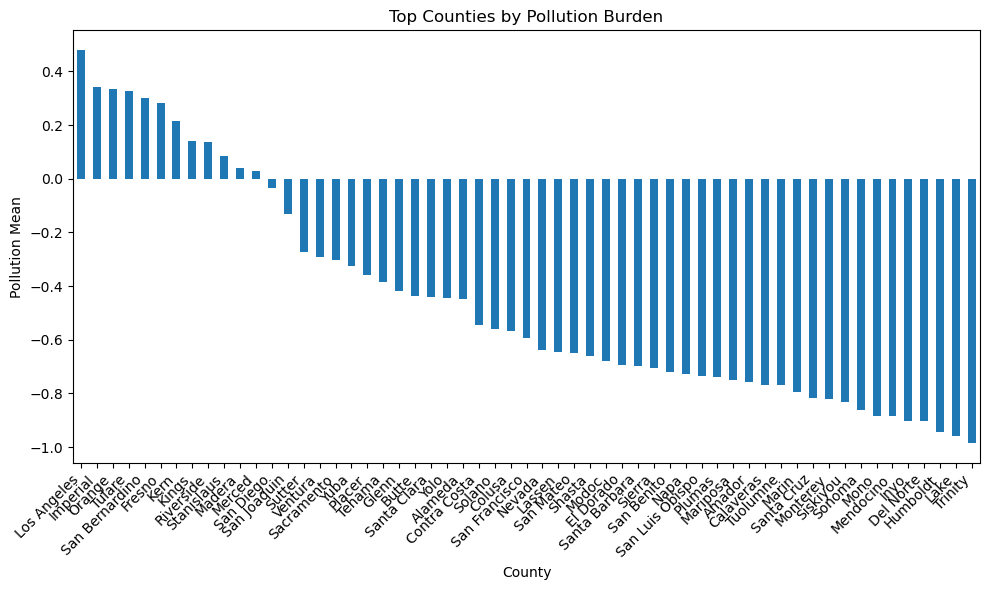

In [121]:
county_env = (df_sorted.groupby("county")["pollution_mean"].mean().sort_values(ascending=False))
county_env.head(15)
county_env.plot(x="county", y="pollution_mean", kind="bar", figsize=(10, 6))
plt.title("Top Counties by Pollution Burden")
plt.xlabel("County")
plt.ylabel("Pollution Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<br><br>

##### **Bar chart of top counties with highest health burden**

/var/folders/7v/rcrf3r9x0_v3n_yky8k3hgkc0000gn/T/ipykernel_13099/2455713943.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  county_health = (df_sorted.groupby("county")["health_mean"].mean().sort_values(ascending=False))


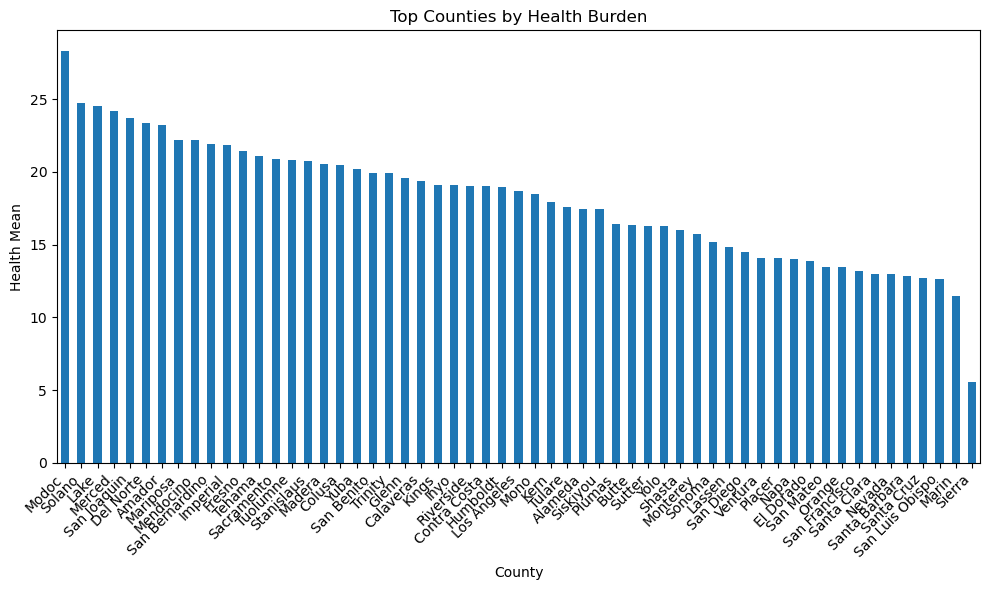

In [122]:
county_health = (df_sorted.groupby("county")["health_mean"].mean().sort_values(ascending=False))
county_health.head(15)
county_health.plot(x="county", y="health_mean", kind="bar", figsize=(10, 6))
plt.title("Top Counties by Health Burden")
plt.xlabel("County")
plt.ylabel("Health Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<br><br>

##### **Top 10 counties by asthma**

In [123]:
var = "asthma"
print(f"\nTop 10 communities by {var}")
df_asthma = df_sorted.sort_values(var, ascending=False)[["census_tract", "county", "location", var, "pollution_mean", "health_mean"]]
df_asthma.head(10)


Top 10 communities by asthma


,census_tract,county,location,asthma,pollution_mean,health_mean
7484,6081613800,San Mateo,Pescadero,246.07,-0.877324,66.8750
5897,6071005800,San Bernardino,San Bernardino,137.08,0.589742,48.5450
5896,6071005701,San Bernardino,San Bernardino,131.21,0.947517,48.5150
7077,6077000102,San Joaquin,Stockton,127.62,0.700266,45.3600
6000,6071009300,San Bernardino,Barstow,124.04,-0.169421,45.5975
6001,6071009400,San Bernardino,Barstow,124.04,0.322418,45.4100
6002,6071009501,San Bernardino,Barstow,124.04,0.239292,45.3400
6109,6071012002,San Bernardino,Barstow,124.04,0.415964,45.0300
6105,6071011801,San Bernardino,Barstow,124.04,-0.110082,44.9500
6003,6071009502,San Bernardino,Barstow,124.04,0.077648,44.5525


<br><br>

##### **Top 10 counties by cardiovascular disease**

In [124]:
var = "cardiovascular_disease"
print(f"\nTop 10 communities by {var}")
df_cardio = df_sorted.sort_values(var, ascending=False)[["census_tract", "county", "location", var, "pollution_mean", "health_mean"]]
df_cardio.head(10)


Top 10 communities by cardiovascular_disease


,census_tract,county,location,cardiovascular_disease,pollution_mean,health_mean
1239,6029005205,Kern,Lake Isabella,37.21,-0.420113,28.4250
6094,6071011205,San Bernardino,Big Bear Lake,37.12,-0.338814,27.9225
6093,6071011204,San Bernardino,Big Bear Lake,36.84,-0.642420,26.8625
1238,6029005203,Kern,Weldon,34.33,-0.537094,26.0375
6000,6071009300,San Bernardino,Barstow,32.92,-0.169421,45.5975
6001,6071009400,San Bernardino,Barstow,32.92,0.322418,45.4100
6002,6071009501,San Bernardino,Barstow,32.92,0.239292,45.3400
6109,6071012002,San Bernardino,Barstow,32.92,0.415964,45.0300
6105,6071011801,San Bernardino,Barstow,32.92,-0.110082,44.9500
6003,6071009502,San Bernardino,Barstow,32.92,0.077648,44.5525


<br><br>

##### **Top 10 counties by diabetes**

In [125]:
var = "diabetes"
print(f"\nTop 10 communities by {var}")
df_diabetes = df_sorted.sort_values(var, ascending=False)[["census_tract", "county", "location", var, "pollution_mean", "health_mean"]]
df_diabetes.head(10)


Top 10 communities by diabetes


,census_tract,county,location,diabetes,pollution_mean,health_mean
1929,6037206302,Los Angeles,Los Angeles,30.9,0.574437,36.8800
7061,6075061101,San Francisco,San Francisco,26.8,-0.201326,16.4300
6851,6075010701,San Francisco,San Francisco,26.8,-0.657082,15.6500
7062,6075061102,San Francisco,San Francisco,26.7,-0.638638,15.1525
5896,6071005701,San Bernardino,San Bernardino,26.1,0.947517,48.5150
6877,6075012502,San Francisco,San Francisco,25.1,-0.340274,21.3875
5107,6065043505,Riverside,Hemet,22.9,-0.101950,27.8725
1038,6025012001,Imperial,Calexico,22.4,0.973821,20.6700
7077,6077000102,San Joaquin,Stockton,22.0,0.700266,45.3600
5104,6065043404,Riverside,Hemet,21.7,-0.162069,32.2575


<br><br>

##### **Top 10 counties by low birth weight**

In [126]:
var = "low_birth_weight"
print(f"\nTop 10 communities by {var}")
df_lbw = df_sorted.sort_values(var, ascending=False)[["census_tract", "county", "location", var, "pollution_mean", "health_mean"]]
df_lbw.head(10)


Top 10 communities by low_birth_weight


,census_tract,county,location,low_birth_weight,pollution_mean,health_mean
743,6019000100,Fresno,Fresno,17.39,0.541407,26.6825
2162,6037234301,Los Angeles,Los Angeles,15.00,0.191476,30.9050
2175,6037236101,Los Angeles,Los Angeles,14.11,0.195923,31.2875
368,6001983200,Alameda,Oakland,13.89,0.286066,26.8875
1798,6037190101,Los Angeles,Los Angeles,13.73,0.414296,15.7050
2193,6037237800,Los Angeles,Los Angeles,13.61,0.186875,36.8150
3775,6037980025,Los Angeles,Carson,13.33,0.672153,25.6350
6873,6075012403,San Francisco,San Francisco,13.16,-0.108205,18.8875
1928,6037206202,Los Angeles,Los Angeles,12.96,0.977457,29.8150
3398,6037601001,Los Angeles,Inglewood,12.20,0.284909,26.3250


<br><br>

## 8. Port Activity

<br>

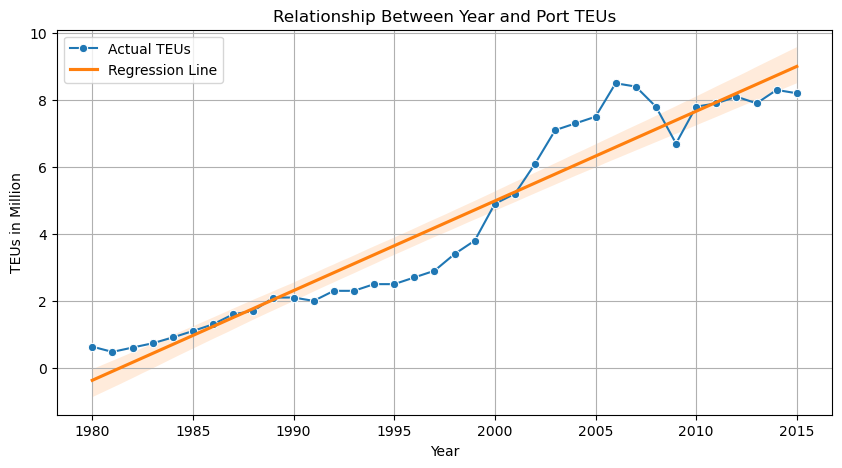

In [127]:
port_clean = pd.read_csv("port_clean.csv")
plt.figure(figsize=(10, 5))
sns.lineplot(data=port_clean, x="Year", y="TEUs in Million", marker="o", label="Actual TEUs")
sns.regplot(data=port_clean, x="Year", y="TEUs in Million", scatter=False, label="Regression Line")
plt.xlabel("Year")
plt.ylabel("TEUs in Million")
plt.title("Relationship Between Year and Port TEUs")
plt.legend()
plt.grid(True)
plt.show()